# 06 — Surprise + Pattern: Does DTW Improve the Surprise Strategy?

## Purpose

The original project plan ends with a three-way comparison:

> **Surprise only** vs **Surprise + State** vs **Surprise + Pattern**

Notebooks 04 and 05 covered the first two. This notebook completes the third arm. It adds a **Dynamic Time Warping (DTW)** pattern signal, the method behind the peer strategy (Jack Duncan, Hoshea Zeng), to the surprise strategy of Notebook 05.

**Question:**

> Does the *shape* of the market's price path around a release add information beyond the *surprise* itself?

**Prior evidence (stated before running):** the team has tested DTW for **direction** many times. Jack's six designs, Hoshea's generalisation test and Aaryen's features at an executable entry all failed to establish a directional DTW edge. The expected result is therefore **no improvement**. This notebook is the first test of DTW **as a confirmation of the surprise**, with our executable entry, our universe and our evaluation.

**Credits:** the DTW specification (31-minute z-scored path, same clock slot, 3-year lookback, 600 most recent, k = 15, Sakoe-Chiba band 5, 1/distance × 2-year-half-life recency weights, middle-40% rank gate) is from the peer DTW strategy (**Jack Duncan, Hoshea Zeng**). The "reaction path" ending at T+1 is Jack's design 5.

## Notebook Workflow

| Step | What happens |
|---|---|
| 1 | Setup and pre-registered parameters |
| 2 | Load the Notebook 05 trade log (surprise strategies and the traded releases) |
| 3 | Rebuild the release calendar and ES price measures (as in Notebook 05) |
| 4 | Build the DTW signal for every release (walk-forward, history only) |
| 5 | Diagnostics: does DTW predict the 30-minute return? Is it related to the surprise? |
| 6 | Strategies: DTW only, surprise + DTW agreement, 50/50 blend (all releases and CPI) |
| 7 | Performance, robustness and paired tests against surprise only |
| 8 | **Final three-model comparison** (Surprise only / + State / + Pattern) |

## Methodology: fixed before looking at results

**DTW signal for a release at time T.**
1. **Query path:** ES log prices from T−30 to T+1 (32 one-minute points), z-scored. It ends at the entry instant, so it includes the first minute of the market's reaction but nothing after entry.
2. **Library:** earlier releases at the **same clock time** (for example all 08:30 releases, of any type), within the last **3 years**, at most the **600** most recent, and only releases whose outcome was known at T (release time < T − 30 min).
3. **Matching:** DTW distance with a 5-minute Sakoe-Chiba band; the **15** nearest paths, weighted by 1/distance × recency (2-year half-life).
4. **Signal:** `dtw_dir` = weighted mean of the neighbours' T+1 → T+30 returns; `dtw_disp` = their weighted standard deviation; `dtw_score = dtw_dir / dtw_disp`.

**Three pre-registered strategies**, on the same releases and window as Notebook 05 (entry T+1, exit T+30):

| Strategy | Rule |
|---|---|
| **DTW only** | Trade the sign of `dtw_score` only if it is outside the middle 40% of its previous-3-year range (the peer rank gate) |
| **Surprise + DTW agreement** | Keep a surprise trade only if DTW points in the **same direction** |
| **Surprise + DTW blend** | Position = ½ × surprise position + ½ × DTW position |

The surprise baselines are Notebook 05's **All · naive** (≈10 releases) and **CPI · surprise model**. Costs, evaluation window (2019–2026) and tests are the same as Notebook 05.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys, importlib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BBG_FILE = RAW_DIR / "Bloomberg Economic Releases.xlsx"
ES_RAW_FILE = RAW_DIR / "ES_1m_2010_2026_full.parquet"
NB05_LOG = RESULTS_DIR / "nb05_trade_log.csv"
NB05_FINAL = RESULTS_DIR / "nb05_final_comparison.csv"
NB04_FINAL = RESULTS_DIR / "nb04_final_comparison.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.walk_forward as wf
import src.surprise_universe as su
import src.dtw_signal as ds
for m in (sc, wf, su, ds):
    importlib.reload(m)

for f in [BBG_FILE, ES_RAW_FILE, NB05_LOG, NB05_FINAL, NB04_FINAL]:
    print(f"{f.name:<40s} exists: {f.exists()}")

Bloomberg Economic Releases.xlsx         exists: True
ES_1m_2010_2026_full.parquet             exists: True
nb05_trade_log.csv                       exists: True
nb05_final_comparison.csv                exists: True
nb04_final_comparison.csv                exists: True


### 1.1 Pre-registered parameters

In [2]:
HIST_START = "2016-01-01"
EVAL_START, EVAL_END = "2019-01-01", "2026-06-30"
EVAL_YEARS = list(range(2019, 2027))
N_YEARS = (pd.Timestamp(EVAL_END) - pd.Timestamp(EVAL_START)).days / 365.25

# DTW specification (peer strategy)
LOOKBACK_YEARS, MAX_POOL, K_NN, BAND, HALF_LIFE = 3, 600, 15, 5, 2.0
GATE_MIDDLE = 0.40          # do not trade the middle 40% of the historical score range
N_NULL, N_BOOT = 1000, 5000

SURPRISE_ALL = "All · naive"            # Notebook 05 multi-release baseline
SURPRISE_CPI = "CPI · surprise model"   # Notebook 05 CPI baseline

## 2. Load the Notebook 05 Trade Log

In [3]:
log5 = pd.read_csv(NB05_LOG)
log5["timestamp_utc"] = pd.to_datetime(log5["timestamp_utc"], utc=True)
base_all = log5[log5["strategy"] == SURPRISE_ALL].sort_values("timestamp_utc").reset_index(drop=True)
base_cpi = log5[log5["strategy"] == SURPRISE_CPI].sort_values("timestamp_utc").reset_index(drop=True)
print(f"{SURPRISE_ALL}: {len(base_all)} release timestamps, {int((base_all['position'] != 0).sum())} trades")
print(f"{SURPRISE_CPI}: {len(base_cpi)} release timestamps, {int((base_cpi['position'] != 0).sum())} trades")
display(base_all[["timestamp_utc", "families", "x", "position", "ret_bps", "cost_bps", "net_bps"]].head())

All · naive: 809 release timestamps, 744 trades
CPI · surprise model: 89 release timestamps, 67 trades


,timestamp_utc,families,x,position,ret_bps,cost_bps,net_bps
0,2019-01-03 15:00:00+00:00,ISM Manufacturing,-1.334,-1.000,-33.430,2.379,31.050
1,2019-01-04 13:30:00+00:00,Employment Report (NFP),0.663,1.000,32.323,2.379,29.945
2,2019-01-07 15:00:00+00:00,ISM Services,-0.521,-1.000,20.719,2.329,-23.049
3,2019-01-11 13:30:00+00:00,CPI,-0.186,-1.000,-11.596,2.281,9.315
4,2019-01-15 13:30:00+00:00,Empire Manufacturing,-0.763,-1.000,3.872,2.285,-6.157


## 3. Release Calendar and ES Paths

In [4]:
t0 = time.time()
rows = su.load_bloomberg(BBG_FILE)
es = sc.load_es_minute(ES_RAW_FILE)
es_adj, _ = sc.build_adjusted_log_price(es)

cal = (rows[rows["ts_utc"] >= pd.Timestamp(HIST_START, tz="UTC")]
       .groupby("ts_utc")["clock_et"].first().reset_index().sort_values("ts_utc").reset_index(drop=True))
px = su.price_measures(es_adj, cal["ts_utc"])
cal = cal.merge(px[["ts_utc", "w1"]], on="ts_utc", how="left")

raw_paths = ds.extract_paths(es_adj, cal["ts_utc"])
paths = ds.zscore_rows(raw_paths)
ok = ~np.isnan(raw_paths).any(axis=1)
print(f"Release timestamps since {HIST_START}: {len(cal):,} | with a complete 32-minute path: {ok.sum():,} "
      f"| clock slots: {cal['clock_et'].nunique()} | {time.time()-t0:.0f}s")

# every Notebook 05 release must be in the calendar, with the same trade return
chk = base_all.merge(cal, left_on="timestamp_utc", right_on="ts_utc", how="left")
print("NB05 releases found in calendar:", chk["ts_utc"].notna().mean().round(4))
print("Max |NB05 ret - w1|:", float((chk["ret_bps"] - chk["w1"]).abs().max()))

Release timestamps since 2016-01-01: 6,097 | with a complete 32-minute path: 5,994 | clock slots: 59 | 1s
NB05 releases found in calendar: 1.0
Max |NB05 ret - w1|: 7.105427357601002e-15


## 4. DTW Signal (walk-forward)

For every release since 2017, the 15 most similar earlier paths at the same clock time are found, using only releases whose outcome was already known. This takes about 20–60 seconds.

In [5]:
t0 = time.time()
qmask = (cal["ts_utc"] >= pd.Timestamp("2017-01-01", tz="UTC")).to_numpy()
sig = ds.compute_dtw_signal(cal["ts_utc"], cal["clock_et"].to_numpy(), paths, cal["w1"].to_numpy(),
                            query_mask=qmask, lookback_years=LOOKBACK_YEARS, max_pool=MAX_POOL,
                            k=K_NN, band=BAND, half_life_years=HALF_LIFE)
print(f"DTW signal computed for {sig['dtw_dir'].notna().sum():,} releases in {time.time()-t0:.0f}s")
display(sig.dropna().describe().T[["count", "mean", "std", "min", "50%", "max"]])

gates = ds.gate_thresholds(sig, EVAL_YEARS, window_years=3, middle=GATE_MIDDLE)
display(pd.DataFrame(gates, index=["lower cut", "upper cut", "n history"]).T)
sig.to_csv(RESULTS_DIR / "nb06_dtw_signal.csv", index=False)

  DTW computed for 1,000 releases ...
  DTW computed for 2,000 releases ...
  DTW computed for 3,000 releases ...
  DTW computed for 4,000 releases ...
  DTW computed for 5,000 releases ...
DTW signal computed for 5,181 releases in 4s


,count,mean,std,min,50%,max
dtw_dir,"5,181.000",0.243,6.031,-33.600,0.151,33.251
dtw_disp,"5,181.000",18.564,11.850,0.000,15.709,109.197
pool,"5,181.000",386.728,214.194,30.000,444.000,600.000
nn_dist,"5,181.000",1.973,0.780,0.000,1.874,5.657
dtw_score,"5,181.000",0.012,0.296,-1.414,0.010,1.217


,lower cut,upper cut,n history
2019,-0.141,0.172,"1,013.000"
2020,-0.156,0.161,"1,570.000"
2021,-0.174,0.172,"1,647.000"
2022,-0.162,0.173,"1,685.000"
2023,-0.150,0.186,"1,630.000"
2024,-0.134,0.185,"1,603.000"
2025,-0.141,0.178,"1,606.000"
2026,-0.143,0.177,"1,652.000"


## 5. Diagnostics

### 5.1 Does the DTW signal predict the 30-minute return?

In [6]:
ev = sig.merge(cal[["ts_utc", "w1"]], on="ts_utc")
ev = ev[(ev["ts_utc"] >= pd.Timestamp(EVAL_START, tz="UTC")) & ev["dtw_dir"].notna() & ev["w1"].notna()]
traded_ts = set(base_all["timestamp_utc"])
ev["in_nb05_universe"] = ev["ts_utc"].isin(traded_ts)

def ic_row(d, label):
    return dict(sample=label, n=len(d),
                rank_ic=d["dtw_score"].corr(d["w1"], method="spearman"),
                pearson_ic=d["dtw_dir"].corr(d["w1"]),
                hit_sign=(np.sign(d["dtw_dir"]) == np.sign(d["w1"])).mean())
diag = pd.DataFrame([ic_row(ev, "all releases 2019-26"),
                     ic_row(ev[ev["in_nb05_universe"]], "NB05 traded releases"),
                     ic_row(ev[ev["clock"] == "08:30"], "08:30 releases"),
                     ic_row(ev[ev["clock"] == "10:00"], "10:00 releases")]).set_index("sample")
display(diag.round(4))

yearly_ic = ev.groupby(ev["ts_utc"].dt.year).apply(lambda d: d["dtw_score"].corr(d["w1"], method="spearman")).rename("rank IC")
display(yearly_ic.to_frame().T.round(3))

,n,rank_ic,pearson_ic,hit_sign
sample,,,,
all releases 2019-26,4093,0.010,0.003,0.492
NB05 traded releases,801,0.012,0.020,0.498
08:30 releases,1119,0.043,0.051,0.505
10:00 releases,1021,-0.019,-0.026,0.492


ts_utc,2019,2020,2021,2022,2023,2024,2025,2026
rank IC,0.048,0.013,0.002,-0.005,-0.011,0.004,0.023,0.026


**How to read it.** A rank IC around 0 means DTW has no directional information. Useful directional signals in this setting typically show an IC of about 0.05–0.10, stable across years. The hit rate should be compared with 50%.

### 5.2 Is DTW related to the surprise?

In [7]:
m = base_all.merge(sig, left_on="timestamp_utc", right_on="ts_utc", how="inner").dropna(subset=["dtw_dir", "x"])
rel = pd.Series({
    "corr(dtw_score, surprise x)": m["dtw_score"].corr(m["x"], method="spearman"),
    "share of releases where signs agree": (np.sign(m["dtw_dir"]) == np.sign(m["x"])).mean(),
    "n releases": len(m),
})
display(rel.to_frame("value").round(3))

,value
"corr(dtw_score, surprise x)",0.113
share of releases where signs agree,0.505
n releases,808.000


The DTW path ends one minute after the release, so it contains the first reaction to the surprise. A positive correlation means DTW partly **re-measures the surprise**. What matters is whether it adds information **beyond** it.

## 6. Strategies

In [8]:
def attach(base):
    t = base.merge(sig[["ts_utc", "dtw_dir", "dtw_disp", "dtw_score"]], left_on="timestamp_utc",
                   right_on="ts_utc", how="left").drop(columns="ts_utc")
    y = t["timestamp_utc"].dt.tz_convert("America/New_York").dt.year
    lo = y.map(lambda v: gates[v][0]); hi = y.map(lambda v: gates[v][1])
    s = t["dtw_score"]
    t["dtw_pos"] = np.where((s < lo) | (s > hi), np.sign(s), 0.0)
    t["dtw_pos"] = t["dtw_pos"].fillna(0.0)
    return t

def build(base, tag):
    t = attach(base)
    out = {}
    out[f"{tag} · surprise only"] = ds.recost(t, f"{tag} · surprise only")
    d = t.copy(); d["position"] = d["dtw_pos"]
    out[f"{tag} · DTW only"] = ds.recost(d, f"{tag} · DTW only")
    a = t.copy(); a["position"] = np.where(np.sign(a["dtw_dir"]) == np.sign(a["position"]), a["position"], 0.0)
    out[f"{tag} · surprise + DTW agree"] = ds.recost(a, f"{tag} · surprise + DTW agree")
    b = t.copy(); b["position"] = 0.5 * b["position"] + 0.5 * b["dtw_pos"]
    out[f"{tag} · surprise + DTW blend"] = ds.recost(b, f"{tag} · surprise + DTW blend")
    return out

T = {**build(base_all, "All"), **build(base_cpi, "CPI")}
STRATS = list(T)
pd.concat(T.values()).to_csv(RESULTS_DIR / "nb06_trade_log.csv", index=False)
display(pd.DataFrame({k: {"trades": int((v["position"] != 0).sum()),
                          "trades / yr": (v["position"] != 0).sum() / N_YEARS} for k, v in T.items()}).T.round(1))

,trades,trades / yr
All · surprise only,744.000,99.300
All · DTW only,490.000,65.400
All · surprise + DTW agree,397.000,53.000
All · surprise + DTW blend,582.000,77.700
CPI · surprise only,67.000,8.900
CPI · DTW only,62.000,8.300
CPI · surprise + DTW agree,49.000,6.500
CPI · surprise + DTW blend,69.000,9.200


## 7. Performance

### 7.1 Main metrics (2019–2026, net of costs)

In [9]:
KEY = ["trades", "hit_rate", "avg_gross_bps", "avg_net_bps", "total_net_pct", "ann_return_pct",
       "ann_vol_pct", "sharpe_gross", "sharpe_net", "max_dd_pct", "t_stat_trade", "profit_factor"]
perf = wf.perf_table(T, EVAL_START, EVAL_END)
perf["trades_per_year"] = perf["trades"] / N_YEARS
perf.to_csv(RESULTS_DIR / "nb06_performance.csv")
display(perf[["trades_per_year"] + KEY].round(3))

,trades_per_year,trades,hit_rate,avg_gross_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,
All · surprise only,98.352,737,0.507,3.148,1.736,12.793,1.706,2.638,1.170,0.647,-4.836,1.823,1.216
All · DTW only,64.589,484,0.469,-0.041,-1.454,-7.036,-0.938,2.409,-0.011,-0.389,-11.004,-1.171,0.858
All · surprise + DTW agree,52.579,394,0.510,2.560,1.138,4.484,0.598,1.912,0.698,0.313,-4.612,0.838,1.128
All · surprise + DTW blend,77.267,579,0.513,1.986,0.980,5.675,0.757,1.832,0.834,0.413,-4.206,1.181,1.163
CPI · surprise only,8.941,67,0.582,9.604,8.228,5.513,0.735,0.972,0.878,0.756,-2.035,2.084,1.969
CPI · DTW only,8.274,62,0.548,4.992,3.621,2.245,0.299,0.931,0.442,0.321,-1.530,0.880,1.357
CPI · surprise + DTW agree,6.539,49,0.612,13.895,12.504,6.127,0.817,0.879,1.023,0.929,-1.169,2.613,2.700
CPI · surprise + DTW blend,9.208,69,0.594,6.906,5.898,4.070,0.543,0.783,0.807,0.693,-1.171,1.906,1.889


### 7.2 Robustness and paired comparison with surprise only

In [10]:
def sharpe_m(tr, a, b, drop_year=None):
    m = wf.monthly_returns(tr, a, b)
    if drop_year:
        m = m[m.index.year != drop_year]
    sd = m.std(ddof=1)
    return m.mean() / sd * np.sqrt(12) if sd > 0 else np.nan

rows_r = []
for s in STRATS:
    base_name = s.split(" · ")[0] + " · surprise only"
    obs, p_null = su.random_sign_pvalue(T[s], wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    row = dict(strategy=s, sharpe=obs,
               sharpe_2019_21=sharpe_m(T[s], "2019-01-01", "2021-12-31"),
               sharpe_2022_26=sharpe_m(T[s], "2022-01-01", EVAL_END),
               sharpe_ex_2022=sharpe_m(T[s], EVAL_START, EVAL_END, 2022),
               p_random_sign=p_null)
    if s != base_name:
        d, (lo, _, hi), p = wf.bootstrap_sharpe_diff(T[base_name], T[s], EVAL_START, EVAL_END, N_BOOT)
        pt = wf.paired_trade_test(T[base_name], T[s], EVAL_START, EVAL_END)
        row.update(sharpe_diff_vs_surprise=d, diff_ci_5=lo, diff_ci_95=hi, p_not_better=p,
                   paired_t=pt["t_stat"])
    rows_r.append(row)
rob = pd.DataFrame(rows_r).set_index("strategy")
rob.to_csv(RESULTS_DIR / "nb06_robustness.csv")
display(rob.round(3))

,sharpe,sharpe_2019_21,sharpe_2022_26,sharpe_ex_2022,p_random_sign,sharpe_diff_vs_surprise,diff_ci_5,diff_ci_95,p_not_better,paired_t
strategy,,,,,,,,,,
All · surprise only,0.647,0.321,0.833,0.275,0.000,NaN,NaN,NaN,NaN,NaN
All · DTW only,-0.389,0.114,-0.626,-0.322,0.479,-1.036,-1.880,-0.172,0.975,-2.243
All · surprise + DTW agree,0.313,0.536,0.203,0.067,0.030,-0.334,-0.744,0.091,0.897,-1.825
All · surprise + DTW blend,0.413,0.687,0.289,0.187,0.009,-0.234,-0.639,0.183,0.813,-1.616
CPI · surprise only,0.756,0.630,0.831,0.049,0.006,NaN,NaN,NaN,NaN,NaN
CPI · DTW only,0.321,0.428,0.309,-0.024,0.097,-0.435,-1.192,0.327,0.826,-1.107
CPI · surprise + DTW agree,0.929,0.829,1.023,0.210,0.000,0.173,-0.149,0.456,0.211,0.560
CPI · surprise + DTW blend,0.693,0.992,0.677,0.060,0.009,-0.063,-0.444,0.311,0.601,-0.973


**How to read it.**
- **`p_not_better`** is the bootstrap probability that adding DTW is *not* better than surprise only. Below 0.05 would be convincing evidence that DTW helps.
- **`p_random_sign`** tests whether the direction beats random directions with the same trades and costs.

### 7.3 Cumulative P&L

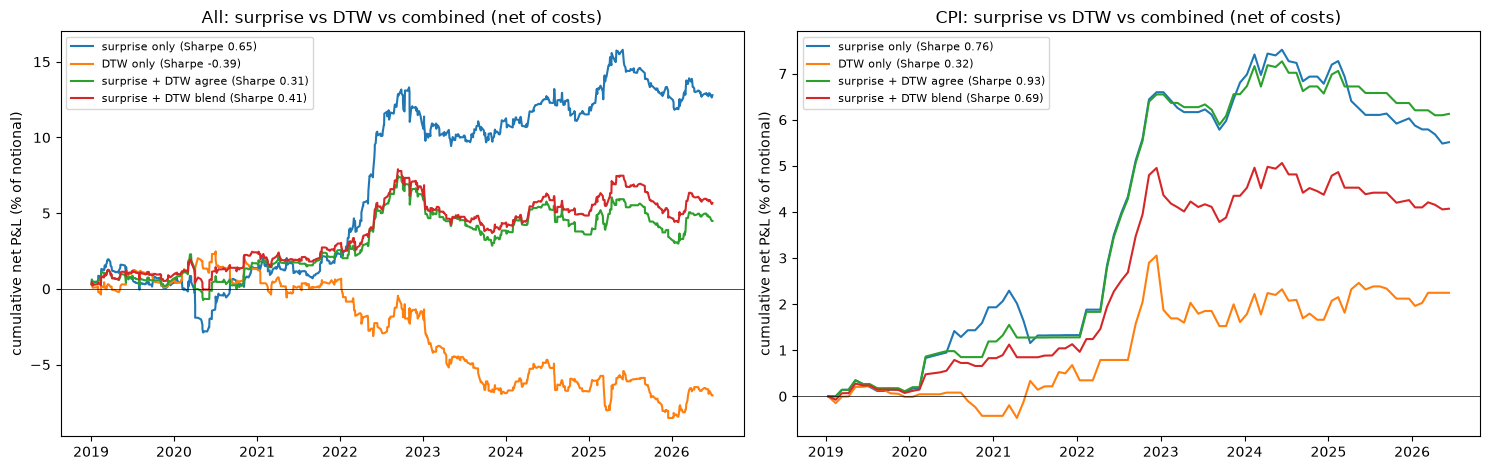

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=False)
for ax, tag in zip(axes, ["All", "CPI"]):
    for i, suffix in enumerate(["surprise only", "DTW only", "surprise + DTW agree", "surprise + DTW blend"]):
        s = f"{tag} · {suffix}"
        cum, _ = wf.drawdown_series(T[s], EVAL_START, EVAL_END)
        ax.plot(cum.index, cum.values, lw=1.5, label=f"{suffix} (Sharpe {perf.loc[s, 'sharpe_net']:.2f})")
    ax.axhline(0, c="k", lw=0.5)
    ax.set_title(f"{tag}: surprise vs DTW vs combined (net of costs)")
    ax.set_ylabel("cumulative net P&L (% of notional)")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb06_cumulative_pnl.png", dpi=150); plt.show()

### 7.4 When surprise and DTW disagree

In [12]:
t = attach(base_all)
t = t[(t["position"] != 0) & t["dtw_dir"].notna()]
t["net"] = t["position"] * t["ret_bps"] - t["cost_bps"]
t["dtw_agrees"] = np.sign(t["dtw_dir"]) == np.sign(t["position"])
agree_tab = t.groupby("dtw_agrees")["net"].agg(trades="size", hit_rate=lambda v: (v > 0).mean(),
                                               avg_net_bps="mean", total_net_pct=lambda v: v.sum() / 100)
display(agree_tab.round(3))

,trades,hit_rate,avg_net_bps,total_net_pct
dtw_agrees,,,,
False,346,0.500,2.444,8.359
True,397,0.506,1.138,4.484


If DTW adds information, surprise trades where **DTW agrees** should clearly beat those where it **disagrees**. Similar numbers in both rows mean DTW is not separating good trades from bad ones.

## 8. Final Comparison: Surprise Only vs Surprise + State vs Surprise + Pattern

In [13]:
rows_f = []
if NB04_FINAL.exists():
    f4 = pd.read_csv(NB04_FINAL, index_col=[0, 1])
    for strat, label in [("Surprise only", "Surprise only — CPI (NB04)"),
                         ("Surprise + State", "Surprise + State — CPI (NB04)"),
                         ("Surprise + Adaptive state", "Surprise + Adaptive state — CPI (NB04)")]:
        if ("CPI", strat) in f4.index:
            r = f4.loc[("CPI", strat)]
            rows_f.append(dict(model=label, trades_per_year=r["trades"] / N_YEARS, net_bps_per_trade=r["avg_net_bps"],
                               sharpe_net=r["sharpe_net"], max_dd_pct=r["max_dd_pct"]))
for s, label in [("All · surprise only", "Surprise only — ~10 releases (NB05)"),
                 ("CPI · surprise only", "Surprise only — CPI model (NB05)"),
                 ("All · surprise + DTW agree", "Surprise + Pattern (agree) — ~10 releases"),
                 ("All · surprise + DTW blend", "Surprise + Pattern (blend) — ~10 releases"),
                 ("CPI · surprise + DTW agree", "Surprise + Pattern (agree) — CPI"),
                 ("All · DTW only", "Pattern only (DTW) — ~10 releases")]:
    r = perf.loc[s]
    rows_f.append(dict(model=label, trades_per_year=r["trades_per_year"], net_bps_per_trade=r["avg_net_bps"],
                       sharpe_net=r["sharpe_net"], max_dd_pct=r["max_dd_pct"],
                       sharpe_ex_2022=rob.loc[s, "sharpe_ex_2022"], p_random_sign=rob.loc[s, "p_random_sign"]))
rows_f.append(dict(model="Peer: Jack DTW (slide, 2018-26)", trades_per_year=185, net_bps_per_trade=1.18,
                   sharpe_net=0.613, max_dd_pct=-4.928))
final = pd.DataFrame(rows_f).set_index("model")
final.to_csv(RESULTS_DIR / "nb06_final_three_model_comparison.csv")
display(final.round(3))

,trades_per_year,net_bps_per_trade,sharpe_net,max_dd_pct,sharpe_ex_2022,p_random_sign
model,,,,,,
Surprise only — CPI (NB04),6.939,12.786,0.988,-1.768,NaN,NaN
Surprise + State — CPI (NB04),6.806,10.395,0.775,-1.793,NaN,NaN
Surprise + Adaptive state — CPI (NB04),6.539,12.679,0.952,-1.683,NaN,NaN
Surprise only — ~10 releases (NB05),98.352,1.736,0.647,-4.836,0.275,0.000
Surprise only — CPI model (NB05),8.941,8.228,0.756,-2.035,0.049,0.006
Surprise + Pattern (agree) — ~10 releases,52.579,1.138,0.313,-4.612,0.067,0.030
Surprise + Pattern (blend) — ~10 releases,77.267,0.980,0.413,-4.206,0.187,0.009
Surprise + Pattern (agree) — CPI,6.539,12.504,0.929,-1.169,0.210,0.000
Pattern only (DTW) — ~10 releases,64.589,-1.454,-0.389,-11.004,-0.322,0.479


### 8.1 Automatic summary

In [14]:
print("=" * 100)
print("NOTEBOOK 06 SUMMARY — does DTW add to the surprise? (ES, 2019-2026, net of costs)")
print("=" * 100)
print("DTW directional information (rank IC vs 30-min return):")
for k, r in diag.iterrows():
    print(f"  {k:<28s} n={int(r.n):>5d}  rank IC={r.rank_ic:+.4f}  hit={r.hit_sign:.1%}")
print()
for s in STRATS:
    r = perf.loc[s]; q = rob.loc[s]
    extra = "" if pd.isna(q.get("p_not_better", np.nan)) else f" | vs surprise: ΔSharpe {q['sharpe_diff_vs_surprise']:+.2f}, P(not better) {q['p_not_better']:.2f}"
    print(f"{s:<32s} {r.trades_per_year:5.0f} tr/yr | Sharpe {r.sharpe_net:5.2f} | {r.avg_net_bps:6.2f} bps | "
          f"random-sign p {q['p_random_sign']:.3f}{extra}")

NOTEBOOK 06 SUMMARY — does DTW add to the surprise? (ES, 2019-2026, net of costs)
DTW directional information (rank IC vs 30-min return):
  all releases 2019-26         n= 4093  rank IC=+0.0100  hit=49.2%
  NB05 traded releases         n=  801  rank IC=+0.0121  hit=49.8%
  08:30 releases               n= 1119  rank IC=+0.0427  hit=50.5%
  10:00 releases               n= 1021  rank IC=-0.0195  hit=49.2%

All · surprise only                 98 tr/yr | Sharpe  0.65 |   1.74 bps | random-sign p 0.000
All · DTW only                      65 tr/yr | Sharpe -0.39 |  -1.45 bps | random-sign p 0.479 | vs surprise: ΔSharpe -1.04, P(not better) 0.97
All · surprise + DTW agree          53 tr/yr | Sharpe  0.31 |   1.14 bps | random-sign p 0.030 | vs surprise: ΔSharpe -0.33, P(not better) 0.90
All · surprise + DTW blend          77 tr/yr | Sharpe  0.41 |   0.98 bps | random-sign p 0.009 | vs surprise: ΔSharpe -0.23, P(not better) 0.81
CPI · surprise only                  9 tr/yr | Sharpe  0.76 |   8.

## 9. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Does DTW predict direction by itself?** Use the rank IC (Section 5.1) and the DTW-only strategy.

**2. Is DTW just re-measuring the surprise?** Use the correlation between the DTW score and the surprise (Section 5.2).

**3. Does DTW improve the surprise strategy?** Compare the agreement and blend strategies with surprise only: Sharpe difference, `P(not better)`, and agree-vs-disagree trades (Section 7.4).

**4. Final three-model answer.** Surprise only vs Surprise + State vs Surprise + Pattern: which one would you recommend, and how confident are you?

# 10. Extra Test: The Ladder: Can We Reach ~185 Trades a Year?

## Why this test

The peer DTW strategy (Jack Duncan) trades about **185 times a year on ES** because it takes **five consecutive 30-minute trades after each release** (T+1, T+31, T+61, T+91, T+121). Our books take **one trade per release**, which caps them at about 108 trades a year on our universe.

This section copies the ladder structure to answer the supervisor's question directly:

> **If we trade five windows after each release, how many trades do we get, and what happens to the Sharpe?**

## Design (fixed before running)

| Window | Entry → exit (bars after the release) | Approx. clock time for an 08:30 release |
|---|---|---|
| 1 | close of bar T → T+29 (same as Sections 1–9) | 08:31 → 09:00 |
| 2 | T+29 → T+59 | 09:00 → 09:30 |
| 3 | T+59 → T+89 | 09:30 → 10:00 |
| 4 | T+89 → T+119 | 10:00 → 10:30 |
| 5 | T+119 → T+149 | 10:30 → 11:00 |

- **Releases:** the same ~108 release timestamps a year as Notebook 05's multi-release book.
- **DTW for window k:** the 31-minute path ending at **that window's entry**, matched against earlier releases at the same clock time, with the neighbours' **window-k** returns as the answer. Neighbours must have finished window k before the current release. The same k = 15, band, lookback, weights and middle-40% gate apply, with the gate computed separately for each window.
- **Surprise for window k:** the sign of the release's surprise (Notebook 05 naive rule), held for that window.
- **Costs:** the same round-trip cost for every window.

**Three books:**
1. **DTW ladder:** DTW in all five windows (closest to the peer structure).
2. **Surprise ladder:** the surprise sign in all five windows.
3. **Surprise W1 + DTW W2–5:** the surprise for the first window, then DTW for the later ones.

**Expected result (stated before running):** Notebook 05 found the surprise's effect is gone within about 30 minutes (window 2 Sharpe −0.79), and Section 5 found no DTW direction in window 1. We therefore expect the trade count to reach the peer's level while the Sharpe falls toward zero.

**Note:** later windows of an 08:30 release can overlap the first window of a 10:00 release on the same day. Each window is treated as a separate trade on one contract, as in the peer strategy.

## 10.1 Window returns and DTW signals for each window

In [15]:
t0 = time.time()
lad = ds.ladder_returns(es_adj, cal["ts_utc"])
assert np.nanmax(np.abs(lad["r1"].to_numpy() - cal["w1"].to_numpy())) < 1e-9, "window 1 must equal w1"
print("Window 1 identical to the Sections 1-9 trade return: OK")

sigs, lgates = {}, {}
for k, (a, b) in enumerate(ds.LADDER, start=1):
    raw_k = ds.extract_paths(es_adj, cal["ts_utc"], end_offset_min=a)
    paths_k = ds.zscore_rows(raw_k)
    sigs[k] = ds.compute_dtw_signal(cal["ts_utc"], cal["clock_et"].to_numpy(), paths_k, lad[f"r{k}"].to_numpy(),
                                    query_mask=qmask, lookback_years=LOOKBACK_YEARS, max_pool=MAX_POOL,
                                    k=K_NN, band=BAND, half_life_years=HALF_LIFE, progress_every=0,
                                    min_gap_min=b + 1)
    lgates[k] = ds.gate_thresholds(sigs[k], EVAL_YEARS, window_years=3, middle=GATE_MIDDLE)
    print(f"Window {k} (bars {a:>3d} -> {b:>3d}): DTW computed for {sigs[k]['dtw_dir'].notna().sum():,} releases")
print(f"Done in {time.time()-t0:.0f}s")

Window 1 identical to the Sections 1-9 trade return: OK
Window 1 (bars   0 ->  29): DTW computed for 5,181 releases
Window 2 (bars  29 ->  59): DTW computed for 5,170 releases
Window 3 (bars  59 ->  89): DTW computed for 5,068 releases
Window 4 (bars  89 -> 119): DTW computed for 5,062 releases
Window 5 (bars 119 -> 149): DTW computed for 4,877 releases
Done in 21s


## 10.2 Build the ladder books

In [16]:
uni = base_all[["timestamp_utc", "position", "x", "cost_bps"]].rename(columns={"position": "surp_pos"})

def window_trades(k, rule):
    a, b = ds.LADDER[k - 1]
    t = uni.merge(lad[["ts_utc", f"r{k}"]], left_on="timestamp_utc", right_on="ts_utc", how="left").drop(columns="ts_utc")
    t = t.merge(sigs[k][["ts_utc", "dtw_dir", "dtw_score"]], left_on="timestamp_utc", right_on="ts_utc", how="left").drop(columns="ts_utc")
    t["ret_bps"] = t[f"r{k}"]
    if rule == "dtw":
        y = t["timestamp_utc"].dt.tz_convert("America/New_York").dt.year
        lo = y.map(lambda v: lgates[k][v][0]); hi = y.map(lambda v: lgates[k][v][1])
        s = t["dtw_score"]
        t["position"] = np.where((s < lo) | (s > hi), np.sign(s), 0.0)
        t["position"] = pd.Series(t["position"]).fillna(0.0).to_numpy()
    else:
        t["position"] = t["surp_pos"]
    t["eligible"] = t["ret_bps"].notna()
    t["release_ts"] = t["timestamp_utc"]
    t["timestamp_utc"] = t["timestamp_utc"] + pd.Timedelta(minutes=a + 1)   # when the trade is entered
    t["window"] = k
    return ds.recost(t, f"{rule} W{k}")

W = {(rule, k): window_trades(k, rule) for rule in ["dtw", "surprise"] for k in range(1, 6)}

def book(parts, name):
    return ds.recost(pd.concat(parts).sort_values("timestamp_utc").reset_index(drop=True), name)

L = {
    "Surprise W1 only (Sections 1-9)": W[("surprise", 1)].assign(strategy="Surprise W1 only (Sections 1-9)"),
    "DTW ladder (5 windows)": book([W[("dtw", k)] for k in range(1, 6)], "DTW ladder (5 windows)"),
    "Surprise ladder (5 windows)": book([W[("surprise", k)] for k in range(1, 6)], "Surprise ladder (5 windows)"),
    "Surprise W1 + DTW W2-5": book([W[("surprise", 1)]] + [W[("dtw", k)] for k in range(2, 6)], "Surprise W1 + DTW W2-5"),
}
pd.concat(L.values()).to_csv(RESULTS_DIR / "nb06_ladder_trade_log.csv", index=False)

## 10.3 Results by window

rank_ic          trades_per_year          avg_net_bps          sharpe_net         
rule                      dtw surprise             dtw surprise         dtw surprise        dtw surprise
window bars                                                                                             
1      T+0 -> T+29      0.012    0.139          64.589   98.352      -1.454    1.736     -0.389    0.647
2      T+29 -> T+59    -0.022    0.008          64.056   97.952      -2.269   -1.566     -0.955   -0.793
3      T+59 -> T+89     0.009   -0.055          60.452   97.818      -2.320   -1.966     -0.382   -0.570
4      T+89 -> T+119    0.028    0.001          63.655   97.818      -0.721   -1.642     -0.220   -0.571
5      T+119 -> T+149  -0.045    0.005          61.120   97.818      -3.616   -2.350     -1.292   -1.163

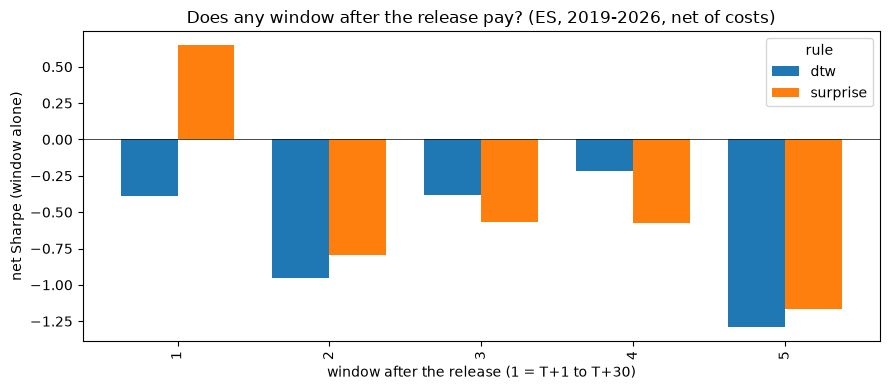

In [17]:
rows_w = []
for k in range(1, 6):
    for rule in ["surprise", "dtw"]:
        t = W[(rule, k)]
        p = wf.performance(t, EVAL_START, EVAL_END, f"{rule} W{k}")
        e = t[t["eligible"] & (t["release_ts"] >= pd.Timestamp(EVAL_START, tz="UTC"))]
        ic = e["dtw_score"].corr(e["ret_bps"], method="spearman") if rule == "dtw" else e["x"].corr(e["ret_bps"], method="spearman")
        rows_w.append(dict(window=k, rule=rule, bars=f"T+{ds.LADDER[k-1][0]} -> T+{ds.LADDER[k-1][1]}",
                           rank_ic=ic, trades_per_year=p["trades"] / N_YEARS, hit_rate=p["hit_rate"],
                           avg_net_bps=p["avg_net_bps"], sharpe_net=p["sharpe_net"], total_net_pct=p["total_net_pct"]))
by_window = pd.DataFrame(rows_w)
by_window.to_csv(RESULTS_DIR / "nb06_ladder_by_window.csv", index=False)
display(by_window.pivot(index=["window", "bars"], columns="rule",
                        values=["rank_ic", "trades_per_year", "avg_net_bps", "sharpe_net"]).round(3))

fig, ax = plt.subplots(figsize=(9, 4))
piv = by_window.pivot(index="window", columns="rule", values="sharpe_net")
piv.plot.bar(ax=ax, width=0.75)
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("net Sharpe (window alone)")
ax.set_xlabel("window after the release (1 = T+1 to T+30)")
ax.set_title("Does any window after the release pay? (ES, 2019-2026, net of costs)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb06_ladder_sharpe_by_window.png", dpi=150); plt.show()

**How to read it.** Window 1 is the trade used in Sections 1–9. If the ladder were worth trading, windows 2–5 would show positive Sharpe and a positive rank IC. For the surprise, the rank IC is the correlation between the surprise and that window's return.

## 10.4 Ladder books: trade count vs Sharpe

,trades_per_year,hit_rate,avg_net_bps,total_net_pct,sharpe_net,sharpe_ex_2022,max_dd_pct,p_random_sign
book,,,,,,,,
Surprise W1 only (Sections 1-9),98.352,0.507,1.736,12.793,0.647,0.275,-4.836,0.000
DTW ladder (5 windows),313.872,0.461,-2.059,-48.436,-1.226,-1.086,-51.230,0.805
Surprise ladder (5 windows),489.758,0.464,-1.155,-42.374,-1.003,-1.082,-45.573,0.344
Surprise W1 + DTW W2-5,347.635,0.473,-1.098,-28.608,-0.745,-0.798,-30.124,0.273
"Peer: Jack DTW (slide, 2018-26)",185.000,NaN,1.180,18.597,0.613,NaN,-4.928,NaN


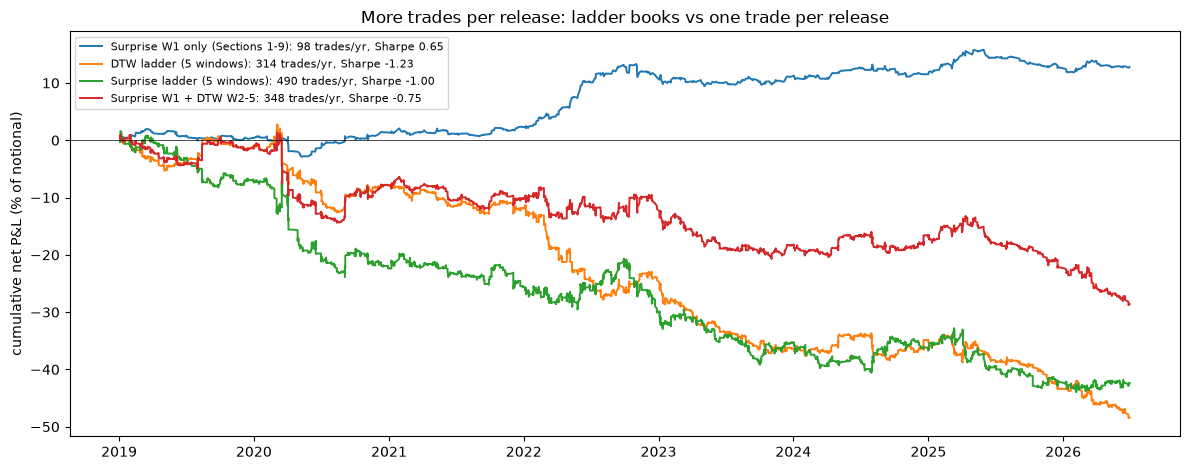

In [18]:
rows_b = []
for name, t in L.items():
    p = wf.performance(t, EVAL_START, EVAL_END, name)
    obs, p_null = su.random_sign_pvalue(t, wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    rows_b.append(dict(book=name, trades_per_year=p["trades"] / N_YEARS, hit_rate=p["hit_rate"],
                       avg_net_bps=p["avg_net_bps"], total_net_pct=p["total_net_pct"],
                       sharpe_net=p["sharpe_net"], sharpe_ex_2022=sharpe_m(t, EVAL_START, EVAL_END, 2022),
                       max_dd_pct=p["max_dd_pct"], p_random_sign=p_null))
rows_b.append(dict(book="Peer: Jack DTW (slide, 2018-26)", trades_per_year=185, avg_net_bps=1.18,
                   total_net_pct=18.597, sharpe_net=0.613, max_dd_pct=-4.928))
ladder_tab = pd.DataFrame(rows_b).set_index("book")
ladder_tab.to_csv(RESULTS_DIR / "nb06_ladder_books.csv")
display(ladder_tab.round(3))

fig, ax = plt.subplots(figsize=(12, 4.8))
for name, t in L.items():
    cum, _ = wf.drawdown_series(t, EVAL_START, EVAL_END)
    ax.plot(cum.index, cum.values, lw=1.4,
            label=f"{name}: {ladder_tab.loc[name, 'trades_per_year']:.0f} trades/yr, Sharpe {ladder_tab.loc[name, 'sharpe_net']:.2f}")
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("cumulative net P&L (% of notional)")
ax.set_title("More trades per release: ladder books vs one trade per release")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb06_ladder_cumulative.png", dpi=150); plt.show()

## 10.5 Summary of the ladder test

In [19]:
print("=" * 100)
print("LADDER TEST — five 30-minute windows per release (ES, 2019-2026, net of costs)")
print("=" * 100)
print("By window (net Sharpe of that window alone):")
for k in range(1, 6):
    s = by_window[(by_window.window == k) & (by_window.rule == "surprise")].iloc[0]
    d = by_window[(by_window.window == k) & (by_window.rule == "dtw")].iloc[0]
    print(f"  W{k} {s.bars:<16s} surprise: IC {s.rank_ic:+.3f}, Sharpe {s.sharpe_net:+.2f} | "
          f"DTW: IC {d.rank_ic:+.3f}, Sharpe {d.sharpe_net:+.2f}, {d.trades_per_year:.0f} tr/yr")
print("\nBooks:")
for name, r in ladder_tab.iterrows():
    print(f"  {name:<34s} {r.trades_per_year:6.0f} trades/yr | {r.avg_net_bps:6.2f} bps/trade | "
          f"Sharpe {r.sharpe_net:5.2f} | maxDD {r.max_dd_pct:6.2f}%")

LADDER TEST — five 30-minute windows per release (ES, 2019-2026, net of costs)
By window (net Sharpe of that window alone):
  W1 T+0 -> T+29      surprise: IC +0.139, Sharpe +0.65 | DTW: IC +0.012, Sharpe -0.39, 65 tr/yr
  W2 T+29 -> T+59     surprise: IC +0.008, Sharpe -0.79 | DTW: IC -0.022, Sharpe -0.96, 64 tr/yr
  W3 T+59 -> T+89     surprise: IC -0.055, Sharpe -0.57 | DTW: IC +0.009, Sharpe -0.38, 60 tr/yr
  W4 T+89 -> T+119    surprise: IC +0.001, Sharpe -0.57 | DTW: IC +0.028, Sharpe -0.22, 64 tr/yr
  W5 T+119 -> T+149   surprise: IC +0.005, Sharpe -1.16 | DTW: IC -0.045, Sharpe -1.29, 61 tr/yr

Books:
  Surprise W1 only (Sections 1-9)        98 trades/yr |   1.74 bps/trade | Sharpe  0.65 | maxDD  -4.84%
  DTW ladder (5 windows)                314 trades/yr |  -2.06 bps/trade | Sharpe -1.23 | maxDD -51.23%
  Surprise ladder (5 windows)           490 trades/yr |  -1.15 bps/trade | Sharpe -1.00 | maxDD -45.57%
  Surprise W1 + DTW W2-5                348 trades/yr |  -1.10 bps/trad

### 10.6 Interpretation (fill in after running)

**1. Trade count:** how close does each ladder book get to the peer's 185 trades a year?

**2. Which windows pay?** Is window 1 the only one with a positive edge, for the surprise and for DTW?

**3. Trade count vs Sharpe:** does adding windows raise or lower the Sharpe compared with one trade per release (Sharpe 0.65 at ~98 trades a year)?

**4. Answer for the supervisor:** can we honestly reach ~185 trades a year, and at what cost in risk-adjusted return?

# Purpose, Research Questions, Answers, and Conclusion (ES)

## Purpose of Notebook 06

The project plan ends with a three-way comparison: **Surprise only** vs **Surprise + State** vs **Surprise + Pattern**. Notebooks 04 and 05 covered the first two. This notebook completes the third by adding a **Dynamic Time Warping (DTW)** pattern signal, the method behind the peer strategy (Jack Duncan, Hoshea Zeng), to the surprise strategy of Notebook 05.

> **Does the *shape* of the market's price path around a release add information beyond the *surprise* itself?**

**Design:** the DTW specification of the peer strategy (31-minute z-scored path ending at entry, the same clock slot, a 3-year lookback, the 600 most recent releases, k = 15, a 5-minute Sakoe-Chiba band, 1/distance × 2-year half-life weights, and a middle-40% rank gate), on the same releases, entry (T+1), exit (T+30), costs and evaluation window (2019–2026) as Notebook 05.

The same notebook was repeated for NQ and ZN (Notebooks 06b); their results are shown for reference at the end.

**Checks:** every Notebook 05 release was found, with identical trade returns (difference 7×10⁻¹⁵ bps). The DTW code was also tested on synthetic data where the outcome depends on the path shape: it recovered the pattern with a rank IC of 0.52 and a 71% hit rate. A null result here is therefore a real finding, not a coding problem.

---

## Research Questions and Answers

### Section 4: Can a DTW signal be built for every release?
**Answer:** Yes. DTW direction and dispersion were computed for **5,181 releases**, each matched against an average of about 390 earlier releases at the same clock time (up to 600), using only information available at the time.

### Section 5.1: Does DTW predict the 30-minute return by itself?
**Answer:** **No.**

| Sample (2019–2026) | Releases | Rank IC | Hit rate |
|---|---|---|---|
| All releases | 4,093 | +0.010 | 49.2% |
| Releases traded in Notebook 05 | 801 | +0.012 | 49.8% |
| 08:30 releases | 1,119 | +0.043 | 50.5% |
| 10:00 releases | 1,021 | −0.019 | 49.2% |

The rank IC is essentially zero, and the hit rate is no better than a coin. By year it ranges from −0.011 to +0.048 with no consistent sign. The best subgroup (08:30) has t ≈ 1.4 and is not significant.

### Section 5.2: Is DTW just re-measuring the surprise?
**Answer:** **No, they are unrelated.** The rank correlation between the DTW score and the surprise is **0.11**, and they point in the same direction on **50.5%** of releases. DTW is independent of the surprise; it simply carries no directional information.

### Section 7.1: Does adding DTW improve the surprise strategy?

**All ~10 releases:**

| Strategy | Trades / yr | Net bps / trade | Net Sharpe | Max DD | Δ Sharpe vs surprise | P(not better) |
|---|---|---|---|---|---|---|
| **Surprise only** | 98 | 1.74 | **0.65** | −4.8% | — | — |
| Surprise + DTW agree | 53 | 1.14 | 0.31 | −4.6% | −0.33 | 0.90 |
| Surprise + DTW blend | 77 | 0.98 | 0.41 | −4.2% | −0.23 | 0.81 |
| DTW only | 65 | −1.45 | −0.39 | −11.0% | −1.04 | 0.97 |

**CPI only:**

| Strategy | Trades / yr | Net bps / trade | Hit rate | Net Sharpe | Max DD | Δ Sharpe | P(not better) |
|---|---|---|---|---|---|---|---|
| Surprise model | 9 | 8.2 | 58% | 0.76 | −2.0% | — | — |
| **Surprise + DTW agree** | 7 | **12.5** | **61%** | **0.93** | **−1.2%** | +0.17 | 0.21 |
| Surprise + DTW blend | 9 | 5.9 | 59% | 0.69 | −1.2% | −0.06 | 0.60 |
| DTW only | 8 | 3.6 | 55% | 0.32 | −1.5% | −0.43 | 0.83 |

**Answer:** For the multi-release book, **DTW makes results worse** in every combination. For CPI, the agreement filter looks better (Sharpe 0.93 vs 0.76, smaller drawdown), but the improvement is **not significant** (P(not better) = 0.21, and the confidence interval includes zero). It rests on only 49 trades, and it is one positive result among six comparisons, about what chance alone would produce.

### Section 7.2: Is it robust?
**Answer:** The surprise-only books remain the most robust. Their direction is significant against random signs (p < 0.001 for all releases, p = 0.006 for CPI). The DTW-only book is not (p = 0.48). The blend and agreement books keep a significant direction only because they still contain the surprise.

### Section 7.4: Does DTW separate good surprise trades from bad ones?
**Answer:** **No.** Surprise trades where DTW **disagreed** earned more (+2.4 bps per trade, 346 trades) than those where DTW **agreed** (+1.1 bps, 397 trades). A useful filter would show the opposite.

---

## Why Combining Gives Fewer Trades Than the Peer Strategy

| Strategy | Trades / yr | Why |
|---|---|---|
| All release timestamps in our universe | ~108 | ~10 screened releases, one trade each |
| Surprise only | 98 | Trades almost every release |
| DTW only | 65 | The rank gate skips the middle 40% (108 × 60%) |
| Surprise + DTW blend | 77 | Opposite signals cancel to zero |
| Surprise + DTW agree | 53 | Both must agree, which happens about half the time |
| *Peer: Jack DTW* | *185* | *~90 releases × **5 consecutive windows** (T+1 … T+121), after the gate* |

Combining two signals can only **filter** the releases available, so the trade count is capped by the **design**, not the model. The peer strategy reaches 185 mainly by trading **five windows per release**. Notebook 05 showed that a second window already **loses money** (Sharpe −0.79), because the surprise's effect is gone within about 30 minutes. Section 10 tests the full five-window structure.

---

## Final Comparison: Surprise Only vs Surprise + State vs Surprise + Pattern

| Model | Trades / yr | Net bps / trade | Net Sharpe | Max DD |
|---|---|---|---|---|
| **Surprise only, CPI** (NB04) | 7 | 12.8 | **0.99** | −1.8% |
| **Surprise only, ~10 releases** (NB05) | **98** | 1.7 | **0.65** | −4.8% |
| Surprise + State, CPI (NB04) | 7 | 10.4 | 0.78 | −1.8% |
| Surprise + Adaptive state, CPI (NB04) | 7 | 12.7 | 0.95 | −1.7% |
| Surprise + Pattern (agree), CPI | 7 | 12.5 | 0.93 | −1.2% |
| Surprise + Pattern (blend), ~10 releases | 77 | 1.0 | 0.41 | −4.2% |
| Pattern only (DTW), ~10 releases | 65 | −1.5 | −0.39 | −11.0% |
| *Peer: Jack DTW (slide, 2018–26)* | *185* | *1.2* | *0.61* | *−4.9%* |

---

# 10. Extra Test: The Ladder: Can We Reach ~185 Trades a Year?

## Purpose

The peer DTW strategy reaches **~185 trades a year on ES** by trading **five consecutive 30-minute windows after each release** (T+1, T+31, T+61, T+91, T+121). Our books trade **one window per release**, which caps them at about 108 trades a year. This section repeats the peer's ladder structure on our releases to answer:

> **If we trade five windows after each release, how many trades do we get, and what happens to the Sharpe?**

**Design (fixed before running):** five consecutive windows after each release (T+1→T+30, T+30→T+60, T+60→T+90, T+90→T+120, T+120→T+150), on the same ~108 release timestamps a year as Notebook 05. For each window, DTW is rebuilt from the 31-minute path ending at **that window's** entry, matched against earlier releases at the same clock time, using only neighbours whose window had already finished, with a separate middle-40% gate per window. The surprise rule holds the sign of the release's surprise in each window. Costs are unchanged.

**Check:** window 1 is identical to the trade used in Sections 1–9.

### Section 10.3: Which windows after the release pay?
**Answer:** **Only the first 30 minutes, and only for the surprise.**

| Window | Surprise: rank IC | Surprise: net Sharpe | DTW: rank IC | DTW: net Sharpe |
|---|---|---|---|---|
| **1: T+1 → T+30** | **+0.139** | **+0.65** | +0.012 | −0.39 |
| 2: T+30 → T+60 | +0.008 | −0.79 | −0.022 | −0.96 |
| 3: T+60 → T+90 | −0.055 | −0.57 | +0.009 | −0.38 |
| 4: T+90 → T+120 | +0.001 | −0.57 | +0.028 | −0.22 |
| 5: T+120 → T+150 | +0.005 | −1.16 | −0.045 | −1.29 |

The surprise's information (rank IC 0.14 in window 1) is **gone after 30 minutes** (IC ≈ 0 in windows 2–5). DTW has no information in **any** window. In windows 2–5 the net loss per trade (about −1 to −4 bps) is roughly the round-trip cost, so the gross edge there is about zero and costs turn it into a loss.

### Section 10.4: What happens to trade count and Sharpe?
**Answer:** **The trade count rises well above the peer's, but every added trade loses money.**

| Book | Trades / yr | Net bps / trade | Total net P&L | Net Sharpe | Max DD |
|---|---|---|---|---|---|
| **Surprise, window 1 only** (Sections 1–9) | **98** | **+1.74** | **+12.8%** | **+0.65** | **−4.8%** |
| Surprise W1 + DTW W2–5 | 348 | −1.10 | −28.6% | −0.75 | −30.1% |
| Surprise ladder (5 windows) | 490 | −1.15 | −42.4% | −1.00 | −45.6% |
| DTW ladder (5 windows) | 314 | −2.06 | −48.4% | −1.23 | −51.2% |
| *Peer: Jack DTW (slide, 2018–26)* | *185* | *+1.18* | *+18.6%* | *+0.61* | *−4.9%* |

The ladder books trade **314–490 times a year**, more than the peer's 185, but the Sharpe falls from **+0.65 to between −0.75 and −1.23**, and drawdowns grow roughly **6–10×**.

---

## The Same Test in NQ and ZN (Notebooks 06b)

| 2019–2026, net of costs | ES | NQ | ZN |
|---|---|---|---|
| Average cost (bps) | 1.7 | 0.8 | 3.0 |
| DTW rank IC (all releases) | +0.010 | +0.026 | +0.039 |
| DTW hit rate | 49.2% | 50.9% | 46.6% |
| **Surprise only, ~10 releases** | **0.65** | **0.71** | −2.42 |
| Surprise + DTW agree | 0.31 | 0.62 | −1.57 |
| Surprise + DTW blend | 0.41 | 0.67 | −1.51 |
| DTW only | −0.39 | 0.08 | −1.25 |
| CPI: surprise model | 0.76 | 0.55 | −0.37 (1 trade) |
| CPI: surprise + DTW agree | 0.93 | 0.54 | no trades |
| CPI: DTW only | 0.32 | 0.81 (not significant) | −0.55 |
| Surprise rank IC, window 1 → windows 2–5 | 0.14 → ≈ 0 | 0.09 → ≈ 0 | ≈ 0 in all |
| Best ladder book (5 windows) | −0.75 | 0.27 | −3.92 |

- **NQ** repeats the ES result: DTW is weak (rank IC 0.03), no combination beats surprise only, and the surprise's information is gone after 30 minutes. Thanks to NQ's low cost the ladder loses less, but every ladder book is still worse than window 1 alone.
- **ZN**: every book loses money. DTW books lose less than the surprise only because they trade less and so pay less cost.
- **The CPI results are not consistent across markets.** In ES the agreement filter looks best; in NQ, DTW alone does. None is significant, so we treat them as noise.

---

## Conclusion

**1. DTW has no directional information at an executable entry.** On ES its rank IC is about 0.01, its hit rate about 49%, and the DTW-only book loses money (Sharpe −0.39). This holds in **all five windows** after the release, not only the first.

**2. DTW is independent of the surprise but does not complement it.** The two signals are unrelated (correlation 0.11), yet adding DTW **lowers** the Sharpe of the multi-release surprise book (0.65 → 0.31–0.41) and does not separate good trades from bad ones.

**3. For CPI, DTW as a confirmation filter is a lead, not a result.** It raises the Sharpe from 0.76 to 0.93 and reduces the drawdown, but the improvement is not statistically significant, rests on 49 trades, and **does not repeat in NQ** (0.55 → 0.54).

**4. The surprise's edge lasts about 30 minutes.** Its information is strong in the first window (rank IC 0.14) and absent afterwards, consistent with Notebook 05's second-window test and with Jack Duncan's entry sweep.

**5. The trade-count question has a clear answer.** We can match or exceed the peer's ~185 trades a year only by trading later windows, and on our data every one of those windows loses money after costs. The honest ceiling is **about 100 trades a year per market at one trade per release**, with a net Sharpe of **0.65** on ES. That matches the peer's 0.61 with about half the trades and more edge per trade (1.74 vs 1.18 bps).

**6. The same holds in NQ and ZN.** In NQ, DTW adds nothing to the surprise book (0.71 → 0.62–0.67) and the ladder dilutes the edge (0.27). In ZN every book loses money. No market shows a significant improvement from DTW over the surprise.

**7. Final answer to the project question: Surprise only is the recommended model.**
- **Surprise + State** (Notebooks 03–04): state variables predict the **size** of moves, but do not improve direction out of sample.
- **Surprise + Pattern** (Notebook 06): DTW does not improve direction in any window or market.
- **Surprise only** delivers a net Sharpe of **~1.0 for CPI** and **~0.65 (ES) to 0.71 (NQ) for ten releases at ~100 trades a year per market**, with an economically grounded signal.

**8. Consistency with the team.** This agrees with Jack Duncan's conclusion that DTW direction is "not established," and adds the first test of DTW as a **confirmation of the surprise** at an executable entry.

**Caveats:**
- Our DTW implementation follows the peer specification but not every detail: flat sizing instead of inverse-dispersion sizing, and our screened ~10 releases instead of the peer's 8 families. Section 10 removes the other difference (one window vs five), and our DTW still has no edge. Our DTW-only result therefore does not directly test the peer's 0.61, which the peer's own README describes as ranging from 0.36 to 0.78 depending on construction choices.
- The DTW parameters were taken from the peer strategy and not tuned. Other settings could give different results, but tuning them on this data would create a selection problem.
- The CPI-only results rest on fewer than 70 trades.
- Later windows of an 08:30 release can overlap the first window of a 10:00 release on the same day. Each window was treated as a separate one-contract trade, as in the peer structure.

> **Overall (Sections 1–10):** across three model families (macro surprise, pre-event state, and DTW price patterns) and three markets (ES, NQ, ZN), only the **macro surprise in the first 30 minutes after a release, in equity index futures,** gives a robust, tradeable directional edge. Pre-event state helps predict the size of the move, DTW adds no directional information in any window, and more windows per release add only losing trades. The recommended book is a CPI core leg plus a multi-release surprise leg: **about 100 trades a year per market at a net Sharpe of about 0.65 (ES) to 0.71 (NQ)**.